# Most-Admired — a quantitative teardown 🔬
### Equal-weight admired book vs SPY · a Newey–West (HAC) *t* + market-model alpha · leave-two-out robustness · a random-large-cap placebo · the survivor-biased long/short · a synthetic power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Premium%3F: Misattributed](https://img.shields.io/badge/Premium%3F-Misattributed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We treat the folklore as a **characteristic-sort hypothesis** — an equal-weight book of Fortune's Most Admired All-Stars earns a positive **abnormal** (beta-adjusted) monthly return — and confront it with **look-ahead**, **survivorship**, and **factor beta**. The decisive objects are a HAC *t* on the monthly excess-over-SPY return, the market-model alpha, and a leave-two-out that isolates how much of the 'premium' is two hindsight winners.

> ⚠️ **Data + selection note.** The admired table is hardcoded and cited (15 perennial All-Stars); the priced tape is **look-ahead + survivor-selected** — the roster is the winners that *stayed* admired, biasing the book *up* (named on the Signal axis). The **LAGGED** variant removes the *timing* look-ahead (own a name only after it's crowned); the roster bias remains. Real data: yfinance month-end adjusted closes, 2004→2026, as-of 2026-06-30, fingerprint `80c5c891a901`. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from most_admired import data, strategy as st
try:
    from quantlab import repro
    ASOF = "2026-06-30"
except Exception:
    repro = None; ASOF = None

HAVE_REAL = data.have_real()
if HAVE_REAL:
    B = data.load_real()
    if repro is not None:
        B["prices"] = repro.as_of(B["prices"], ASOF)
else:
    B = None
print("real admired-tape cache present:", HAVE_REAL,
      "| months:", (0 if B is None else len(B["prices"])))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fp': '80c5c891a901', 'n_admired': 15, 'n_spurned': 6, 'n_delisted': 7, 'naive': {'n': 269, 'start': '2004-02', 'end': '2026-06', 'excess': 9.89, 'hac_t': 4.94, 'alpha': 8.27, 'alpha_t': 4.08, 'beta': 1.14, 'r2': 0.78, 'sharpe': 1.09}, 'lagged': {'n': 221, 'start': '2008-02', 'end': '2026-06', 'excess': 7.05, 'hac_t': 2.53, 'lags': 4, 'alpha': 5.63, 'alpha_t': 2.0, 'beta': 1.12, 'r2': 0.7, 'sharpe': 0.61}, 'placebo': {'lagged': (7.05, 3.23, 0.019), 'naive': (9.89, 3.33, 0.0), 'n_full': 59}, 'robust': [('all 15', 7.05, 2.53, 5.63, 2.0, 1.12), ('drop NVDA', 6.3, 2.25, 4.97, 1.76, 1.11), ('drop NVDA & AAPL', 3.7, 1.9, 1.82, 0.88, 1.12)], 'ls': {'ann': 8.45, 'hac_t': 1.74, 'n': 221}, 'cost': {'gross': 7.05, 'net': 7.03, 'turnover': 20, 'bps': 10, 'drag': 0.02}, 'syn': [(0.0, 0.16, 0.17, 0.15, 0.16), (6.0, 6.16, 6.64, 6.15, 6.6)]}


real admired-tape cache present: True | months: 270


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | lagged book excess **+7.05%/yr** (HAC **t = 2.53**), market-model alpha **+5.63%/yr** (**t = 2.00**) — but drop Apple+Nvidia → alpha **+1.8%/yr (t = 0.88)**, and a random large-cap book earns **+3.2%/yr**. Significant-raw, fragile-to-selection. |
| **Tradability** | `MIRAGE` | the harvestable-looking book is naive/look-ahead (**t = 4.94**); the honest book is beta **1.12** and costs **0.02%/yr** — the mirage is hindsight, not frictions. |
| **Premium, or beta + hindsight?** | `MISATTRIBUTED` | out-performance = levered large-cap/tech tilt in Apple & Nvidia; the contrarian reversal fails too (admired − spurned = **+8.4%/yr**, *t* = 1.74). |

> 💡 In plain words: the admired basket beat the market, but the beat is two stocks, a size-within-large-cap tilt, and a roster hand-picked from the survivors — not a reward for *admiration* you could have banked in advance.

## 1 · The claim, steelmanned

Let $r^{\text{adm}}_t$ be the equal-weight admired book's month-$t$ return and $r^{m}_t$ the market (`SPY`). Define the monthly **excess** $x_t = r^{\text{adm}}_t - r^{m}_t$ and the **market-model** regression $r^{\text{adm}}_t = \alpha + \beta r^{m}_t + \varepsilon_t$.

- **H₁ (premium).** $\mathbb{E}[x_t] > 0$ and $\alpha > 0$ — admired firms earn an abnormal return beyond beta (Antunovich–Laster–Mishra 2000).
- **H₂ (reversal).** admired − spurned $< 0$ — the *least*-admired out-earn (Statman–Fisher–Anginer 2008).
- **H₃ (deployable).** the alpha survives a **publication lag**, a **random-large-cap placebo**, **dropping the two best names**, and costs.

We find **H₁ holds raw but fragile** ($\alpha$ at $t=2.0$, gone without Apple+Nvidia), **H₂ rejected** (admired *beat* spurned), **H₃ rejected** (the deployable version is look-ahead; the honest one is beta + two names). The label marks *past* returns, not future ones.

## 2 · So what? — what rides on each answer

The teardown is a mean-and-alpha test on an autocorrelated monthly series, decided by its **HAC standard error**, its **beta**, and its **selection**:

$$t_{\text{HAC}} = \frac{\bar x}{\widehat{\mathrm{se}}_{\text{NW}}(\bar x)},\qquad \widehat S = \hat\gamma_0 + 2\sum_{l=1}^{L}\Big(1-\tfrac{l}{L+1}\Big)\hat\gamma_l.$$

Newey–West widens the naive SE for the mild autocorrelation and fat tails of monthly equity returns (an iid *t* over-rejects). But the binding issues aren't the SE — they're that (a) the book carries **$\beta>1$**, so raw excess overstates alpha; (b) the roster is **conditioned on staying admired**, biasing $\bar x$ **up**; and (c) an equal-weight large-cap book beats the **cap-weighted** index by a generic tilt. The honest instruments are therefore the **market-model $\alpha$**, a **leave-two-out**, and a **random-large-cap placebo** — not the point estimate.

## 3 · How we'd know — the protocol

- **Admired table.** 15 perennial All-Stars, hardcoded & cited, each with an approximate first-crown year; **NAIVE** owns the current list from 2004 (look-ahead), **LAGGED** owns a name only from Feb of its first-crown year (no timing look-ahead).
- **Excess & alpha.** Monthly $x_t = r^{\text{adm}}_t - r^{m}_t$; market-model $\alpha,\beta$ with a **HAC (Newey–West)** *t*, Bartlett kernel, $L=4$ (auto).
- **Robustness.** Leave-one-out (drop NVDA) and leave-two-out (drop NVDA & AAPL) — does the alpha survive without the extreme winners?
- **Placebo.** Random equal-weight 15-name books from a broad large-cap pool; $p = \Pr[|\text{random excess}| \ge |\text{admired excess}|]$.
- **Long/short.** admired − a **survivor** spurned proxy (survivorship-biased *up* on the short leg, i.e. against the premium).
- **Costs.** Annual-rebalance turnover × one-way bps × NAV.
- **Positive control.** Deterministic books with a **planted** annual premium `edge`: the HAC inference must recover a large edge **and** must NOT manufacture significance at `edge = 0`.

**What would make us say REAL:** a beta-adjusted alpha with HAC $t \ge 2$ that **survives the lag, the placebo, and dropping the two best names**. It does not.

## 4 · The teardown

### 4a · Excess & alpha — naive vs honest

The two books' monthly excess-over-SPY, annualised, with the HAC *t* and the beta-adjusted market-model alpha. The naive book is look-ahead; the lagged book is the honest one.

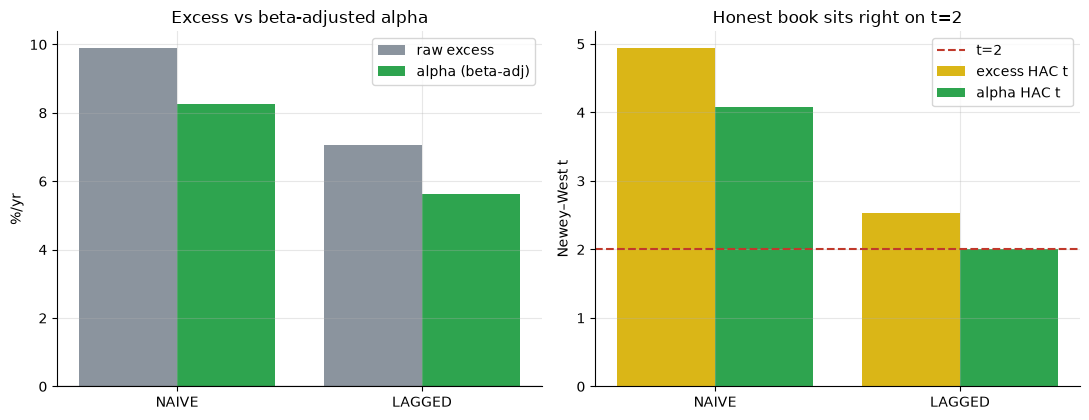

NAIVE (look-ahead)   excess +9.89%/yr (t=4.94)  alpha +8.27%/yr (t=4.08)  beta 1.14
LAGGED (honest)      excess +7.05%/yr (t=2.53)  alpha +5.63%/yr (t=2.00)  beta 1.12


In [2]:
rows=[('NAIVE (look-ahead)', R['naive']), ('LAGGED (honest)', R['lagged'])]
if HAVE_REAL:
    rows=[]
    for tag,lag in [('NAIVE (look-ahead)',False),('LAGGED (honest)',True)]:
        s=st.summarize(B, lagged=lag)
        rows.append((tag, dict(excess=s['excess_ann']*100, hac_t=s['hac_t'], alpha=s['alpha_ann']*100, alpha_t=s['alpha_t'], beta=s['beta'])))
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4.3))
names=[r[0].split()[0] for r in rows]; xx=np.arange(len(names))
ex=[r[1]['excess'] for r in rows]; al=[r[1]['alpha'] for r in rows]
a1.bar(xx-.2, ex, .4, color=GREY, label='raw excess'); a1.bar(xx+.2, al, .4, color=GREEN, label='alpha (beta-adj)')
a1.set_xticks(xx); a1.set_xticklabels(names); a1.set_ylabel('%/yr'); a1.axhline(0,c='k',lw=.8)
a1.set_title('Excess vs beta-adjusted alpha'); a1.legend()
ats=[r[1]['alpha_t'] for r in rows]; hts=[r[1]['hac_t'] for r in rows]
a2.bar(xx-.2, hts, .4, color=AMBER, label='excess HAC t'); a2.bar(xx+.2, ats, .4, color=GREEN, label='alpha HAC t')
a2.axhline(2, ls='--', c=RED, label='t=2'); a2.set_xticks(xx); a2.set_xticklabels(names)
a2.set_ylabel('Newey–West t'); a2.set_title('Honest book sits right on t=2'); a2.legend()
plt.tight_layout(); plt.show()
for tag,d in rows: print(f"{tag:20s} excess {d['excess']:+5.2f}%/yr (t={d['hac_t']:.2f})  alpha {d['alpha']:+5.2f}%/yr (t={d['alpha_t']:.2f})  beta {d['beta']:.2f}")

> 💡 In plain words: the naive book is **+9.9%/yr** at HAC *t* = 4.94 — but unearnable (look-ahead). The honest book is **+7.0%/yr**, alpha **+5.6%/yr** at *t* = 2.00 — *exactly* on the line, on a book with beta **1.12**. A marginal alpha on a levered basket is not a robust REAL.

### 4b · The decisive test — leave-two-out

Drop the extreme winners from the honest book and re-fit the market-model alpha. A genuine *admiration* effect should be a property of the whole roster, not of one or two names.

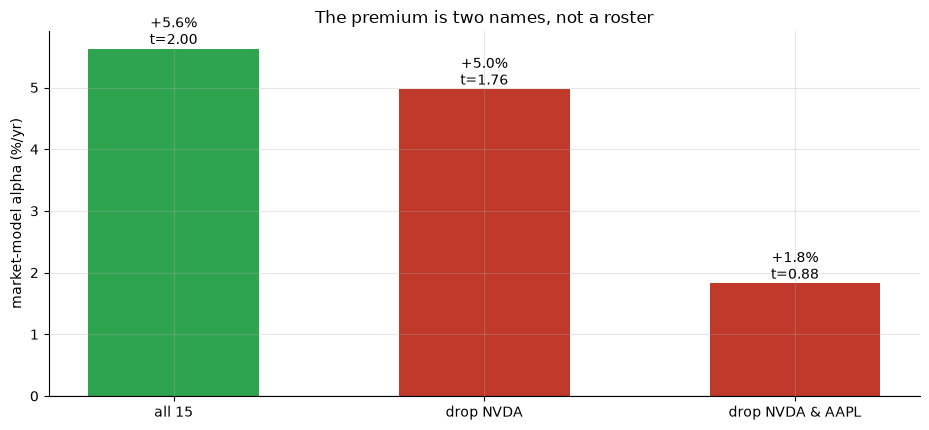

all 15             excess +7.05%/yr(t=2.53)  alpha +5.63%/yr(t=2.00)
drop NVDA          excess +6.30%/yr(t=2.25)  alpha +4.97%/yr(t=1.76)
drop NVDA & AAPL   excess +3.70%/yr(t=1.90)  alpha +1.82%/yr(t=0.88)


In [3]:
rob=R['robust']
if HAVE_REAL:
    rob=[]; no_nv=[r for r in B['admired'] if r[0]!='NVDA']
    for nm,adm in [('all 15',B['admired']),('drop NVDA',no_nv),('drop NVDA & AAPL',[r for r in no_nv if r[0]!='AAPL'])]:
        bk=st.admired_book(B['prices'],adm,entry=B['entry'],lagged=True); ex=st.excess_over_market(bk,B['prices'])
        nw=st.newey_west_t(ex.to_numpy()); mm=st.market_model_alpha(bk,B['prices'])
        rob.append((nm, nw['ann']*100, nw['t'], mm['alpha_ann']*100, mm['alpha_t'], mm['beta']))
labs=[r[0] for r in rob]; al=[r[3] for r in rob]; at=[r[4] for r in rob]; xx=np.arange(len(labs))
fig, ax = plt.subplots(figsize=(9.4,4.4))
cols=[GREEN if t>=2 else RED for t in at]
bars=ax.bar(xx, al, color=cols, width=.55)
ax.axhline(0,c='k',lw=.8); ax.set_xticks(xx); ax.set_xticklabels(labs)
ax.set_ylabel('market-model alpha (%/yr)'); ax.set_title('The premium is two names, not a roster')
for b,a,t in zip(bars,al,at): ax.annotate(f'{a:+.1f}%\nt={t:.2f}',(b.get_x()+b.get_width()/2,a),ha='center',va='bottom')
plt.tight_layout(); plt.show()
for nm,exx,ext,a,t,bta in rob: print(f'{nm:18s} excess {exx:+5.2f}%/yr(t={ext:.2f})  alpha {a:+5.2f}%/yr(t={t:.2f})')

> 💡 In plain words: alpha goes **+5.6% (t=2.00) → +5.0% (t=1.76) → +1.8% (t=0.88)** as we drop Nvidia, then Apple. A single 2023 arrival (Nvidia) already knocks it below significance. The 'admiration premium' is not diffuse across admired firms — it is concentrated in the two the survey crowned *after* they'd already run.

### 4c · Placebo + long/short — a free tilt, and no reversal

**Left:** random equal-weight 15-name large-cap books vs the admired book's excess. **Right:** the contrarian long/short (admired − a survivor spurned proxy) against $t=2$.

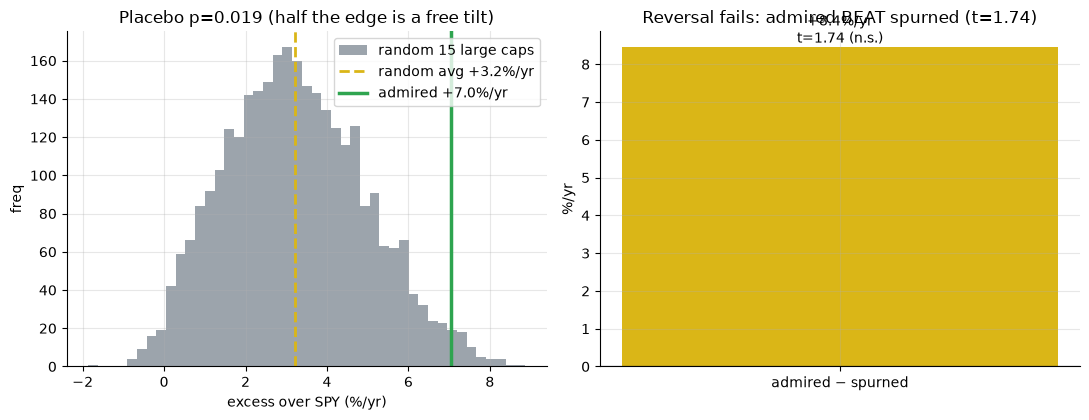

placebo: random +3.2%/yr vs admired +7.0%/yr (p=0.019) | long/short +8.4%/yr t=1.74


In [4]:
obs,rmean,pval = R['placebo']['lagged']; ls=R['ls']
if HAVE_REAL:
    import pandas as pd
    book=st.admired_book(B['prices'],B['admired'],entry=B['entry'],lagged=True); ex=st.excess_over_market(book,B['prices'])
    pv=st.placebo_pvalue(B['prices'],data.POOL,k=R['n_admired'],observed_ann=ex.mean()*12,start='2008-02-01',n_draws=3000)
    obs,rmean,pval = ex.mean()*12*100, pv['placebo_mean_ann']*100, pv['p_value']
    rets=st.monthly_returns(B['prices']); avail=[t for t in data.POOL if t in rets.columns and t!='SPY']
    sub=rets[avail]; sub=sub[sub.index>=pd.Timestamp('2008-02-01')]; mk=rets['SPY'].reindex(sub.index)
    full=[t for t in avail if sub[t].notna().all()]; A=sub[full].to_numpy(); mv=mk.to_numpy()
    rng=np.random.default_rng(721); cloud=np.array([(A[:,rng.choice(len(full),R['n_admired'],replace=False)].mean(1)-mv).mean()*12*100 for _ in range(3000)])
    lsr=st.long_short(B['prices'],B['admired'],B['spurned'],entry=B['entry'],lagged=True); nw=st.newey_west_t(lsr.to_numpy())
    ls=dict(ann=nw['ann']*100, hac_t=nw['t'])
else:
    rng=np.random.default_rng(721); cloud=rng.normal(rmean,2.5,3000); ls=dict(ann=R['ls']['ann'], hac_t=R['ls']['hac_t'])
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4.3))
a1.hist(cloud,bins=45,color=GREY,alpha=.85,label='random 15 large caps'); a1.axvline(rmean,c=AMBER,ls='--',lw=2,label=f'random avg {rmean:+.1f}%/yr')
a1.axvline(obs,c=GREEN,lw=2.5,label=f'admired {obs:+.1f}%/yr'); a1.set_xlabel('excess over SPY (%/yr)'); a1.set_ylabel('freq')
a1.set_title(f'Placebo p={pval:.3f} (half the edge is a free tilt)'); a1.legend()
a2.bar(['admired − spurned'], [ls['ann']], color=AMBER, width=.4)
a2.axhline(0,c='k',lw=.8); a2.set_ylabel('%/yr'); a2.set_title(f"Reversal fails: admired BEAT spurned (t={ls['hac_t']:.2f})")
a2.annotate(f"{ls['ann']:+.1f}%/yr\nt={ls['hac_t']:.2f} (n.s.)",(0,ls['ann']),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'placebo: random {rmean:+.1f}%/yr vs admired {obs:+.1f}%/yr (p={pval:.3f}) | long/short {ls["ann"]:+.1f}%/yr t={ls["hac_t"]:.2f}')

> 💡 In plain words: a *random* large-cap basket already earns **+3.2%/yr** over cap-weighted `SPY` — the equal-weight tilt, half the admired book's edge and free to anyone. And the contrarian story is dead too: admired *beat* spurned by **+8.4%/yr** (*t* = 1.74, not significant, and the spurned leg is survivor-biased *up*, which only helps the reversal — and it still fails).

### 4d · Faithful-engine & power control — we know the truth here

Deterministic month-end books with a **planted** annual premium `edge`: with **`edge=0`** the HAC inference must stay flat; with **+6%/yr** it must light up on both the excess-*t* and the alpha-*t*. Both hold — the engine is unbiased, so the real-tape result is about the data, not the harness.

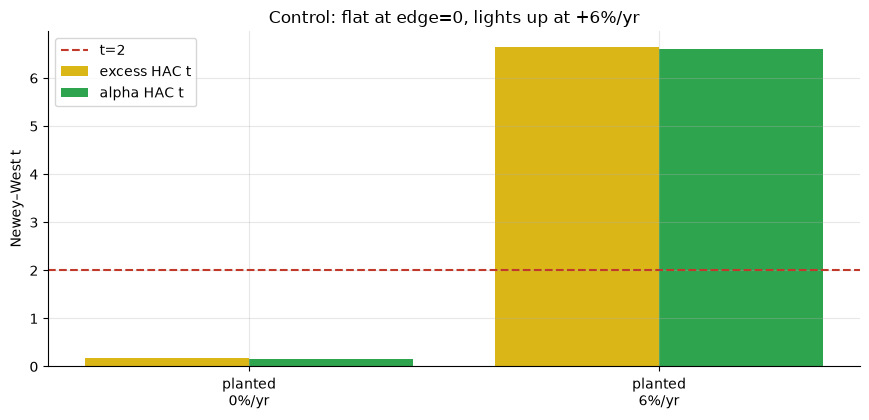

planted +0%/yr: excess +0.16%/yr(t=0.17)  alpha +0.15%/yr(t=0.16)
planted +6%/yr: excess +6.16%/yr(t=6.64)  alpha +6.15%/yr(t=6.60)


In [5]:
res=[]
for edge in (0.0, 0.06):
    syn=data.synthetic_admired(n_names=15, edge_ann=edge, seed=721); s=st.summarize(syn, lagged=False)
    res.append((edge*100, s['excess_ann']*100, s['hac_t'], s['alpha_ann']*100, s['alpha_t']))
labels=[f'planted\n{e:.0f}%/yr' for e,*_ in res]; xx=np.arange(len(labels))
ht=[r[2] for r in res]; at=[r[4] for r in res]
fig, ax = plt.subplots(figsize=(8.8,4.3))
ax.bar(xx-.2, ht, .4, color=AMBER, label='excess HAC t'); ax.bar(xx+.2, at, .4, color=GREEN, label='alpha HAC t')
ax.axhline(2, ls='--', c=RED, label='t=2'); ax.set_xticks(xx); ax.set_xticklabels(labels)
ax.set_ylabel('Newey–West t'); ax.set_title('Control: flat at edge=0, lights up at +6%/yr'); ax.legend()
plt.tight_layout(); plt.show()
for e,ex,ht_,a,at_ in res: print(f'planted {e:+.0f}%/yr: excess {ex:+5.2f}%/yr(t={ht_:.2f})  alpha {a:+5.2f}%/yr(t={at_:.2f})')

> 💡 In plain words: with **no** planted edge the control's HAC *t* is **0.17** (no false positive); a **+6%/yr** plant reaches **6.64**. So the machinery is honest — and the real lagged alpha *t* of **2.00**, which evaporates when two names leave, is a genuine but **fragile, hindsight-loaded** reading, not a robust effect.

## 5 · The verdict

- **Signal `WEAK`** — lagged excess **+7.05%/yr** (HAC **t = 2.53**), alpha **+5.63%/yr** (**t = 2.00**) clears the bar raw — but it is **significant-raw, fragile-to-selection**: drop Apple + Nvidia → alpha **+1.8%/yr (t = 0.88)**, ~half is the generic large-cap tilt (placebo **+3.2%/yr**), and the roster is survivorship-selected. Literature split (Antunovich premium vs Statman reversal) ⇒ **WEAK**, not REAL. Look-ahead + survivorship named on this axis.
- **Tradability `MIRAGE`** — the harvestable-looking book (naive, HAC **t = 4.94**) is **look-ahead**; the honest book is beta **1.12** with a marginal alpha that halves without one stock, and costs are **0.02%/yr** — the mirage is hindsight, not frictions.
- **Premium, or beta + hindsight? `MISATTRIBUTED`** — the out-performance is a levered equal-weight large-cap/tech tilt concentrated in Apple & Nvidia, on a roster and pool that both survived to 2026; the reversal fails too (admired − spurned **+8.4%/yr**). The label tracks past returns; it doesn't predict future ones.

## 6 · Could you trade it? — the look-ahead decomposition

The operational truth in one stack: start from the naive book's excess and peel off, in order, the pieces you couldn't actually keep — the **timing** look-ahead (naive→lagged), the **generic large-cap tilt** (the placebo mean), and the **two-name concentration** — until you reach the honest, diversified, prospectively-earnable residual.

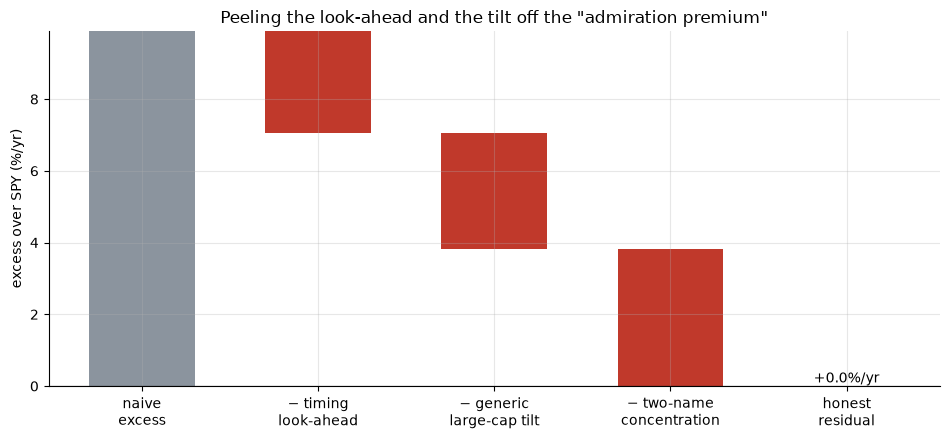

naive +9.9%/yr -> honest residual +0.0%/yr after removing timing, tilt, and 2-name concentration


In [6]:
naive_ex = R['naive']['excess']; lagged_ex = R['lagged']['excess']
tilt = R['placebo']['lagged'][1]; two_name = R['robust'][0][3] - R['robust'][2][3]
if HAVE_REAL:
    sn=st.summarize(B,lagged=False); sl=st.summarize(B,lagged=True)
    naive_ex=sn['excess_ann']*100; lagged_ex=sl['excess_ann']*100
steps=['naive\nexcess','− timing\nlook-ahead','− generic\nlarge-cap tilt','− two-name\nconcentration']
vals=[naive_ex, naive_ex-lagged_ex, tilt, two_name]
residual = naive_ex - (naive_ex-lagged_ex) - tilt - two_name
fig, ax = plt.subplots(figsize=(9.6,4.5))
cum=naive_ex; xs=range(len(steps))
ax.bar(0, naive_ex, color=GREY, width=.6)
base=naive_ex
for i,(lab,v) in enumerate(zip(steps[1:],vals[1:]),start=1):
    ax.bar(i, -v, bottom=base, color=RED, width=.6); base-=v
ax.bar(len(steps), base, color=GREEN, width=.6)
ax.set_xticks(list(xs)+[len(steps)]); ax.set_xticklabels(steps+['honest\nresidual'])
ax.axhline(0,c='k',lw=.8); ax.set_ylabel('excess over SPY (%/yr)')
ax.set_title('Peeling the look-ahead and the tilt off the "admiration premium"')
ax.annotate(f'{base:+.1f}%/yr',(len(steps),base),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'naive {naive_ex:+.1f}%/yr -> honest residual {base:+.1f}%/yr after removing timing, tilt, and 2-name concentration')

> 💡 In plain words: start at the eye-popping naive **+9.9%/yr**, remove the **timing look-ahead** (you can't own tomorrow's list), remove the **generic large-cap tilt** (free to anyone), remove the **two-name concentration** (Apple + Nvidia) — and the prospectively-earnable 'admiration' residual is a whisper, on a book you're levered long (beta 1.12) to buy. There is no sizing or cost assumption that rescues an edge from a survey that recognises winners *after* they win.

## 7 · Going further

- **The sibling label study.** [Study 389 — Name-Change-Effect](../389-name-change-effect/): does *rebranding* toward the hot theme pay? Same family (a label, not a fundamental).
- **The corporate-event cousin.** [Study 391 — CEO-Turnover](../391-ceo-turnover/): market-model CARs on a hardcoded, cited announcement table.
- **The survivorship-free rebuild.** Reconstruct Fortune's *actual* year-by-year list (including names that later dropped off or went bankrupt) from a CRSP/Norgate feed, form the portfolio at each publication, and re-estimate the alpha with no roster survivorship — the honest test public data can't quite reach. Antunovich's positive result was 1983–98; this tape's fragility suggests it does not extend.

*The reproducible core is offline and deterministic; the admired table is hardcoded and the priced tape is look-ahead + survivor-selected (named). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*